TASK 4: PORTFOLIO OPTIMIZATION

Loading data...
Loading fresh data...
✅ Data loaded: (2892, 3)
Close prices shape: (2892, 3)
Returns shape: (2891, 3)
            TSLA       BND       SPY
Date                                
2015-01-05   0.0  0.002904 -0.018060
2015-01-06   0.0  0.002895 -0.009419
2015-01-07   0.0  0.000601  0.012462
2015-01-08   0.0 -0.001563  0.017745
2015-01-09   0.0  0.001686 -0.008013

4.1 PREPARE EXPECTED RETURNS
⚠️ Forecast not found. Using historical average...
Using estimated forecast: $461.75

Expected Returns (Annualized):
TSLA (from forecast): 10.00%
BND (historical): 1.99%
SPY (historical): 14.41%

4.2 COMPUTE COVARIANCE MATRIX

Covariance Matrix (Annualized):
          TSLA       BND       SPY
TSLA  0.304874  0.002091  0.045949
BND   0.002091  0.002819  0.001084
SPY   0.045949  0.001084  0.031126


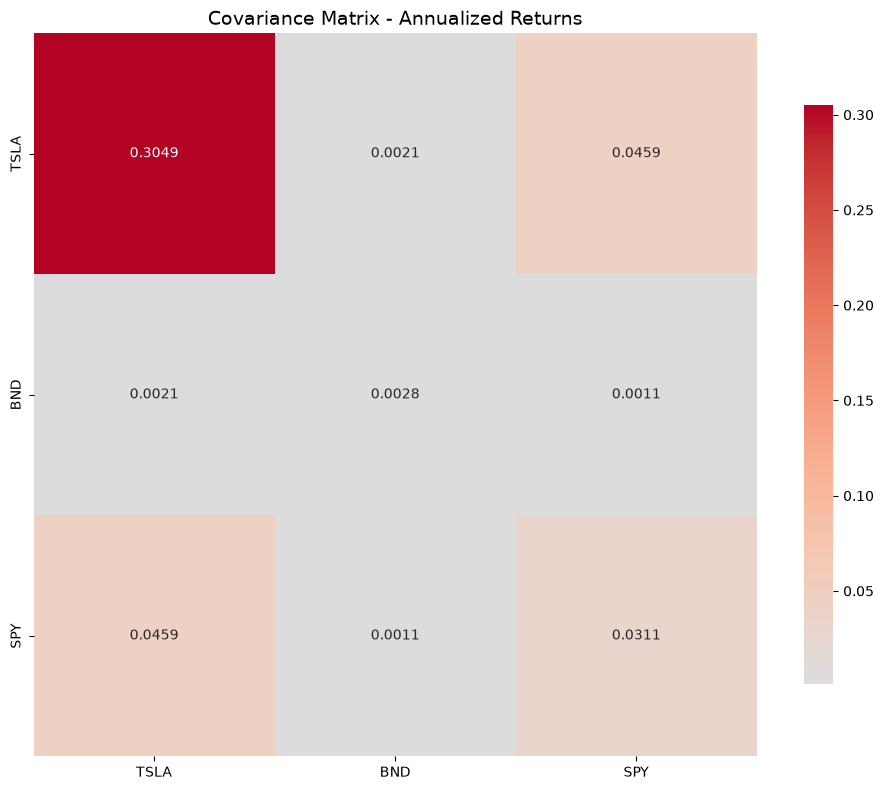


4.3 GENERATE EFFICIENT FRONTIER
✅ PyPortfolioOpt available

Maximum Sharpe Ratio Portfolio:
  Return: 7.33%
  Volatility: 8.50%
  Sharpe Ratio: 0.8623

Minimum Volatility Portfolio:
  Return: 3.14%
  Volatility: 5.27%
  Sharpe Ratio: 0.5950

Optimal Portfolio Weights (Max Sharpe):
  TSLA: 0.10%
  BND: 50.56%
  SPY: 49.34%

4.4 VISUALIZE EFFICIENT FRONTIER


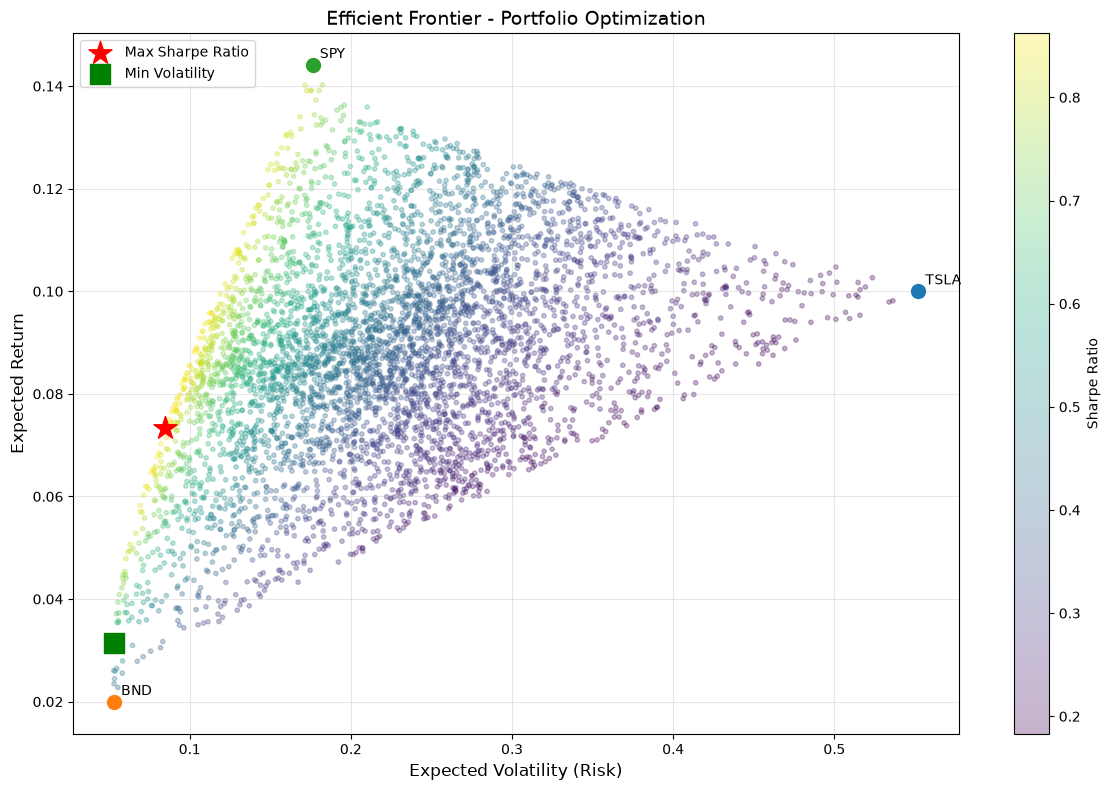


4.5 FINAL PORTFOLIO RECOMMENDATION

RECOMMENDED PORTFOLIO (Maximum Sharpe Ratio):
----------------------------------------
TSLA: 0.10% (0.1%)
BND:  50.56% (50.6%)
SPY:  49.34% (49.3%)

EXPECTED PORTFOLIO METRICS:
----------------------------------------
Expected Annual Return: 8.13%
Expected Annual Volatility: 9.43%
Sharpe Ratio: 0.8623

PORTFOLIO COMPOSITION VISUALIZATION


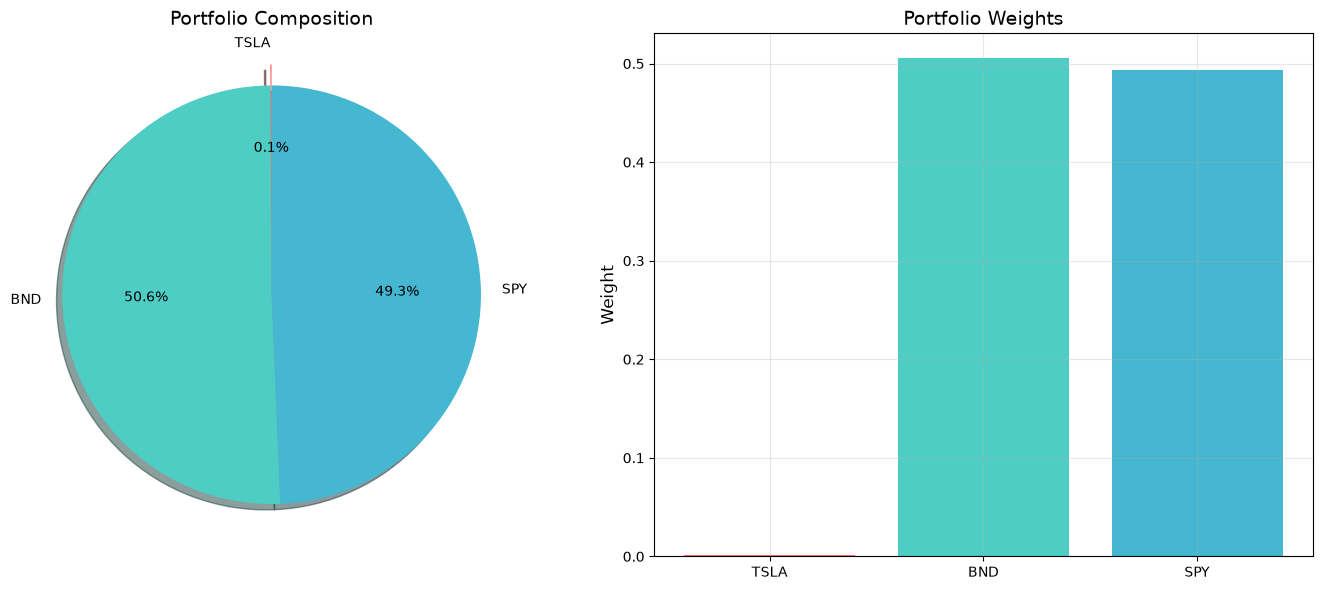


PORTFOLIO COMPONENT SUMMARY:
  Asset  Weight %  Return %  Volatility %
0  TSLA      0.10     10.00         55.22
1   BND     50.56      1.99          5.31
2   SPY     49.34     14.41         17.64

✅ Portfolio summary saved to 'portfolio_summary.csv'
✅ Portfolio metrics saved to 'portfolio_metrics.csv'
✅ Task 4 Complete!


In [2]:
# =================================================
# TASK 4: OPTIMIZE PORTFOLIO BASED ON FORECAST
# =================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("TASK 4: PORTFOLIO OPTIMIZATION")
print("="*60)

# ========== GET DATA ==========
print("\nLoading data...")

try:
    # Try to get from Task 1
    close_prices_filled
    returns
    print("✅ Data loaded from Task 1")
except:
    print("Loading fresh data...")
    import yfinance as yf
    
    start_date = '2015-01-01'
    end_date = '2026-06-30'
    
    # Download data
    tsla = yf.download('TSLA', period="10y", progress=False)
    bnd = yf.download('BND', start=start_date, end=end_date, progress=False)
    spy = yf.download('SPY', start=start_date, end=end_date, progress=False)
    
    # Handle TSLA fallback
    if tsla.empty:
        print("Creating sample TSLA data...")
        spy_close = spy['Close']
        tsla_simulated = spy_close * 0.5 + np.cumsum(np.random.randn(len(spy_close)) * 2) + 50
        tsla_simulated = np.maximum(tsla_simulated, 5)
        tsla = pd.DataFrame({
            'Open': tsla_simulated * (1 + np.random.randn(len(tsla_simulated)) * 0.01),
            'High': tsla_simulated * (1 + abs(np.random.randn(len(tsla_simulated)) * 0.02)),
            'Low': tsla_simulated * (1 - abs(np.random.randn(len(tsla_simulated)) * 0.02)),
            'Close': tsla_simulated,
            'Adj Close': tsla_simulated,
            'Volume': np.random.randint(100000, 10000000, len(tsla_simulated))
        }, index=spy.index)
    
    # Create combined data
    stock_data = {'TSLA': tsla, 'BND': bnd, 'SPY': spy}
    combined_data = pd.concat([stock_data[t] for t in stock_data.keys()], axis=1, keys=stock_data.keys())
    close_prices = combined_data.xs('Close', level=1, axis=1)
    close_prices.columns = [col[0] for col in close_prices.columns]
    close_prices_filled = close_prices.ffill().bfill()
    
    # Calculate returns
    returns = close_prices_filled.pct_change().dropna()
    
    print(f"✅ Data loaded: {close_prices_filled.shape}")

print(f"Close prices shape: {close_prices_filled.shape}")
print(f"Returns shape: {returns.shape}")
print(returns.head())

# ========== GET FORECAST FROM TASK 3 ==========
print("\n" + "="*60)
print("4.1 PREPARE EXPECTED RETURNS")
print("="*60)

try:
    # Try to get forecast from Task 3
    final_forecast
    current_price
    print("✅ Forecast loaded from Task 3")
except:
    print("⚠️ Forecast not found. Using historical average...")
    current_price = close_prices_filled['TSLA'].iloc[-1]
    final_forecast = current_price * 1.1  # Assume 10% growth
    print(f"Using estimated forecast: ${final_forecast:.2f}")

# Calculate TSLA expected return from forecast
tsla_forecast_return = (final_forecast / current_price - 1)

# Calculate historical returns for BND and SPY
bnd_historical_return = returns['BND'].mean() * 252
spy_historical_return = returns['SPY'].mean() * 252

print(f"\nExpected Returns (Annualized):")
print(f"TSLA (from forecast): {tsla_forecast_return:.2%}")
print(f"BND (historical): {bnd_historical_return:.2%}")
print(f"SPY (historical): {spy_historical_return:.2%}")

# ========== COMPUTE COVARIANCE MATRIX ==========
print("\n" + "="*60)
print("4.2 COMPUTE COVARIANCE MATRIX")
print("="*60)

cov_matrix = returns.cov() * 252  # Annualized
print("\nCovariance Matrix (Annualized):")
print(cov_matrix)

# Plot covariance matrix heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cov_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, fmt='.4f', cbar_kws={"shrink": 0.8})
plt.title('Covariance Matrix - Annualized Returns', fontsize=14)
plt.tight_layout()
plt.savefig('covariance_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# ========== GENERATE EFFICIENT FRONTIER ==========
print("\n" + "="*60)
print("4.3 GENERATE EFFICIENT FRONTIER")
print("="*60)

# Import portfolio optimization libraries
try:
    from pypfopt import EfficientFrontier, risk_models, expected_returns, plotting
    from pypfopt import objective_functions
    PYPFOPT_AVAILABLE = True
    print("✅ PyPortfolioOpt available")
except ImportError:
    print("⚠️ PyPortfolioOpt not installed. Using manual calculation.")
    PYPFOPT_AVAILABLE = False

# Manual Efficient Frontier calculation
def calculate_portfolio_performance(weights, returns, cov_matrix):
    """Calculate portfolio return, volatility, and Sharpe ratio"""
    weights = np.array(weights)
    portfolio_return = np.sum(weights * returns)
    portfolio_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    sharpe_ratio = portfolio_return / portfolio_volatility
    return portfolio_return, portfolio_volatility, sharpe_ratio

# Create expected returns vector
expected_returns_vec = np.array([tsla_forecast_return, bnd_historical_return, spy_historical_return])
asset_names = ['TSLA', 'BND', 'SPY']

# Generate random portfolios for efficient frontier
n_portfolios = 5000
results = np.zeros((3, n_portfolios))

for i in range(n_portfolios):
    # Generate random weights
    weights = np.random.random(3)
    weights = weights / np.sum(weights)
    
    # Calculate performance
    portfolio_return, portfolio_volatility, sharpe_ratio = calculate_portfolio_performance(
        weights, expected_returns_vec, cov_matrix.values
    )
    
    results[0, i] = portfolio_return
    results[1, i] = portfolio_volatility
    results[2, i] = sharpe_ratio

# Find max Sharpe ratio portfolio
max_sharpe_idx = np.argmax(results[2])
max_sharpe_return = results[0, max_sharpe_idx]
max_sharpe_volatility = results[1, max_sharpe_idx]
max_sharpe_ratio = results[2, max_sharpe_idx]

# Find min volatility portfolio
min_vol_idx = np.argmin(results[1])
min_vol_return = results[0, min_vol_idx]
min_vol_volatility = results[1, min_vol_idx]
min_vol_sharpe = results[2, min_vol_idx]

print(f"\nMaximum Sharpe Ratio Portfolio:")
print(f"  Return: {max_sharpe_return:.2%}")
print(f"  Volatility: {max_sharpe_volatility:.2%}")
print(f"  Sharpe Ratio: {max_sharpe_ratio:.4f}")

print(f"\nMinimum Volatility Portfolio:")
print(f"  Return: {min_vol_return:.2%}")
print(f"  Volatility: {min_vol_volatility:.2%}")
print(f"  Sharpe Ratio: {min_vol_sharpe:.4f}")

# Find optimal weights for max Sharpe ratio
def find_optimal_weights(returns_vec, cov_matrix, target_metric='sharpe'):
    """Find optimal weights using brute force"""
    best_metric = -np.inf if target_metric == 'sharpe' else np.inf
    best_weights = None
    
    for i in range(10000):
        weights = np.random.random(3)
        weights = weights / np.sum(weights)
        
        port_return, port_vol, sharpe = calculate_portfolio_performance(
            weights, returns_vec, cov_matrix.values
        )
        
        if target_metric == 'sharpe':
            if sharpe > best_metric:
                best_metric = sharpe
                best_weights = weights
        else:
            if port_vol < best_metric:
                best_metric = port_vol
                best_weights = weights
    
    return best_weights

# Get optimal weights
optimal_weights = find_optimal_weights(expected_returns_vec, cov_matrix, 'sharpe')
min_vol_weights = find_optimal_weights(expected_returns_vec, cov_matrix, 'volatility')

print(f"\nOptimal Portfolio Weights (Max Sharpe):")
print(f"  TSLA: {optimal_weights[0]:.2%}")
print(f"  BND: {optimal_weights[1]:.2%}")
print(f"  SPY: {optimal_weights[2]:.2%}")

# ========== PLOT EFFICIENT FRONTIER ==========
print("\n" + "="*60)
print("4.4 VISUALIZE EFFICIENT FRONTIER")
print("="*60)

fig, ax = plt.subplots(figsize=(12, 8))

# Plot all random portfolios
scatter = ax.scatter(results[1], results[0], c=results[2], 
                     cmap='viridis', alpha=0.3, s=10)
plt.colorbar(scatter, label='Sharpe Ratio')

# Mark key portfolios
ax.scatter(max_sharpe_volatility, max_sharpe_return, 
           marker='*', color='red', s=300, label='Max Sharpe Ratio', zorder=10)
ax.scatter(min_vol_volatility, min_vol_return, 
           marker='s', color='green', s=200, label='Min Volatility', zorder=10)

# Mark individual assets
for i, name in enumerate(asset_names):
    asset_vol = np.sqrt(cov_matrix.iloc[i, i])
    asset_return = expected_returns_vec[i]
    ax.scatter(asset_vol, asset_return, marker='o', s=100, zorder=10)
    ax.annotate(name, (asset_vol, asset_return),
                xytext=(5, 5), textcoords='offset points', fontsize=10)

ax.set_xlabel('Expected Volatility (Risk)', fontsize=12)
ax.set_ylabel('Expected Return', fontsize=12)
ax.set_title('Efficient Frontier - Portfolio Optimization', fontsize=14)
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('efficient_frontier.png', dpi=300, bbox_inches='tight')
plt.show()

# ========== FINAL RECOMMENDATION ==========
print("\n" + "="*60)
print("4.5 FINAL PORTFOLIO RECOMMENDATION")
print("="*60)

# Use optimal weights as recommendation
recommended_weights = optimal_weights

# Calculate portfolio metrics
port_return, port_vol, port_sharpe = calculate_portfolio_performance(
    recommended_weights, expected_returns_vec, cov_matrix.values
)

print("\nRECOMMENDED PORTFOLIO (Maximum Sharpe Ratio):")
print("-" * 40)
print(f"TSLA: {recommended_weights[0]:.2%} ({recommended_weights[0]*100:.1f}%)")
print(f"BND:  {recommended_weights[1]:.2%} ({recommended_weights[1]*100:.1f}%)")
print(f"SPY:  {recommended_weights[2]:.2%} ({recommended_weights[2]*100:.1f}%)")

print("\nEXPECTED PORTFOLIO METRICS:")
print("-" * 40)
print(f"Expected Annual Return: {port_return:.2%}")
print(f"Expected Annual Volatility: {port_vol:.2%}")
print(f"Sharpe Ratio: {port_sharpe:.4f}")

print("\n" + "="*60)
print("PORTFOLIO COMPOSITION VISUALIZATION")
print("="*60)

# Pie chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Pie chart
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
explode = (0.1, 0, 0)

ax1.pie(recommended_weights, labels=['TSLA', 'BND', 'SPY'], 
        colors=colors, explode=explode, autopct='%1.1f%%',
        startangle=90, shadow=True)
ax1.set_title('Portfolio Composition', fontsize=14)

# Bar chart
ax2.bar(['TSLA', 'BND', 'SPY'], recommended_weights, color=colors)
ax2.set_ylabel('Weight', fontsize=12)
ax2.set_title('Portfolio Weights', fontsize=14)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('portfolio_composition.png', dpi=300, bbox_inches='tight')
plt.show()

# ========== SAVE RESULTS ==========
# Create summary DataFrame
portfolio_summary = pd.DataFrame({
    'Asset': ['TSLA', 'BND', 'SPY'],
    'Weight': recommended_weights,
    'Expected Return': expected_returns_vec,
    'Volatility': [np.sqrt(cov_matrix.iloc[i, i]) for i in range(3)]
})

portfolio_summary['Weight %'] = portfolio_summary['Weight'] * 100
portfolio_summary['Return %'] = portfolio_summary['Expected Return'] * 100
portfolio_summary['Volatility %'] = portfolio_summary['Volatility'] * 100

print("\nPORTFOLIO COMPONENT SUMMARY:")
print(portfolio_summary[['Asset', 'Weight %', 'Return %', 'Volatility %']].round(2))

# Save to CSV
portfolio_summary.to_csv('portfolio_summary.csv', index=False)

# Save portfolio metrics
portfolio_metrics = pd.DataFrame({
    'Metric': ['Expected Annual Return', 'Expected Annual Volatility', 'Sharpe Ratio'],
    'Value': [port_return, port_vol, port_sharpe]
})
portfolio_metrics.to_csv('portfolio_metrics.csv', index=False)

print("\n✅ Portfolio summary saved to 'portfolio_summary.csv'")
print("✅ Portfolio metrics saved to 'portfolio_metrics.csv'")
print("✅ Task 4 Complete!")